In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

In [2]:
N_MACHINES = 150
MIN_LIFECYCLE_CYCLES = 400
MAX_LIFECYCLE_CYCLES = 900

In [3]:
def simulate_lifecycle(machine_id: int, failure_cycle: int) -> pd.DataFrame:
    cycle = np.arange(1, failure_cycle + 1)
    wear_fraction = cycle / failure_cycle

    return pd.DataFrame(
        {
            "machine_id": machine_id,
            "cycle": cycle,
            "air_temperature_k": (
                298.5 + 1.5 * wear_fraction + rng.normal(0, 0.3, len(cycle))
            ),
            "process_temperature_k": (
                308.0 + 2.0 * wear_fraction + rng.normal(0, 0.4, len(cycle))
            ),
            "rotational_speed_rpm": (
                1500 + 350 * wear_fraction + rng.normal(0, 70, len(cycle))
            ),
            "torque_nm": (
                40 + 14 * wear_fraction + rng.normal(0, 3, len(cycle))
            ),
            "tool_wear_min": (
                5 + 220 * wear_fraction + rng.normal(0, 5, len(cycle))
            ),
            "rul_cycles": failure_cycle - cycle,
        }
    )

In [4]:
example_lifecycle = simulate_lifecycle(
    machine_id=1,
    failure_cycle=600,
)

example_lifecycle.iloc[[0, -1]]

,machine_id,cycle,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,rul_cycles
0,1,1,298.593915,308.209497,1408.005454,39.904214,3.136320,599
599,1,600,299.467511,309.576688,1818.989149,55.766110,223.329396,0


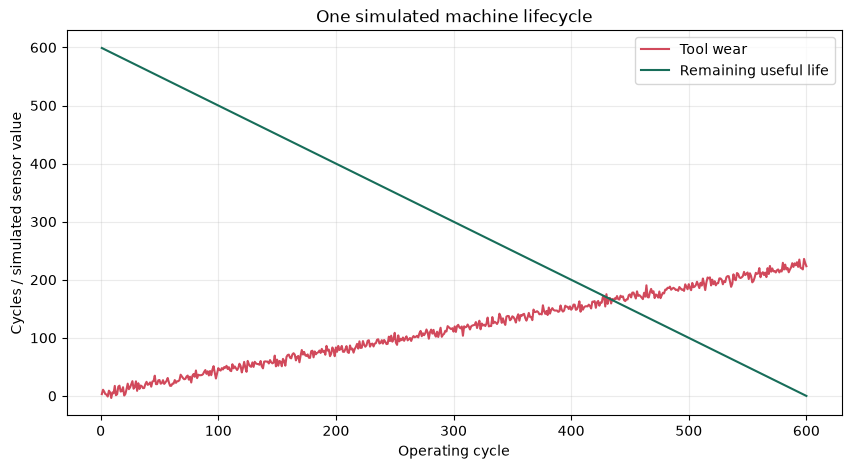

In [5]:
plt.figure(figsize=(10, 5))

plt.plot(
    example_lifecycle["cycle"],
    example_lifecycle["tool_wear_min"],
    label="Tool wear",
    color="#D1495B",
)

plt.plot(
    example_lifecycle["cycle"],
    example_lifecycle["rul_cycles"],
    label="Remaining useful life",
    color="#176D59",
)

plt.xlabel("Operating cycle")
plt.ylabel("Cycles / simulated sensor value")
plt.title("One simulated machine lifecycle")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [6]:
rng = np.random.default_rng(RANDOM_STATE)

lifecycles = []

for machine_id in range(1, N_MACHINES + 1):
    failure_cycle = int(
        rng.integers(MIN_LIFECYCLE_CYCLES, MAX_LIFECYCLE_CYCLES + 1)
    )

    lifecycles.append(
        simulate_lifecycle(
            machine_id=machine_id,
            failure_cycle=failure_cycle,
        )
    )

rul_df = pd.concat(lifecycles, ignore_index=True)

rul_df.shape

(97308, 8)

In [7]:
rul_df.head(), rul_df["rul_cycles"].describe()

(   machine_id  cycle  air_temperature_k  process_temperature_k  \
 0           1      1         298.191383             307.413761   
 1           1      2         298.731892             308.435898   
 2           1      3         298.792305             307.880918   
 3           1      4         297.928203             308.463855   
 4           1      5         298.126238             308.175873   
 
    rotational_speed_rpm  torque_nm  tool_wear_min  rul_cycles  
 0           1381.508788  40.841818       6.548830         443  
 1           1443.264006  41.298978       0.383836         442  
 2           1463.323843  45.673079      13.798263         441  
 3           1474.565949  41.531784      11.027956         440  
 4           1506.642120  42.131322       7.954673         439  ,
 count    97308.000000
 mean       339.359775
 std        211.895210
 min          0.000000
 25%        162.000000
 50%        324.000000
 75%        494.000000
 max        898.000000
 Name: rul_cycles, dt

In [8]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_index, test_index = next(
    splitter.split(rul_df, groups=rul_df["machine_id"])
)

train_df = rul_df.iloc[train_index].copy()
test_df = rul_df.iloc[test_index].copy()

print("Training machines:", train_df["machine_id"].nunique())
print("Test machines:", test_df["machine_id"].nunique())

Training machines: 120
Test machines: 30


In [9]:
rul_feature_columns = [
    "cycle",
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
]

X_train = train_df[rul_feature_columns]
X_test = test_df[rul_feature_columns]

y_train = train_df["rul_cycles"]
y_test = test_df["rul_cycles"]

In [10]:
from sklearn.ensemble import RandomForestRegressor

rul_model = RandomForestRegressor(
    n_estimators=60,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rul_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",60
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

In [11]:
from sklearn.metrics import mean_absolute_error, r2_score

rul_predictions = rul_model.predict(X_test)

mae = mean_absolute_error(y_test, rul_predictions)
r2 = r2_score(y_test, rul_predictions)

print(f"MAE: {mae:.1f} cycles")
print(f"R²: {r2:.3f}")

MAE: 34.9 cycles
R²: 0.934


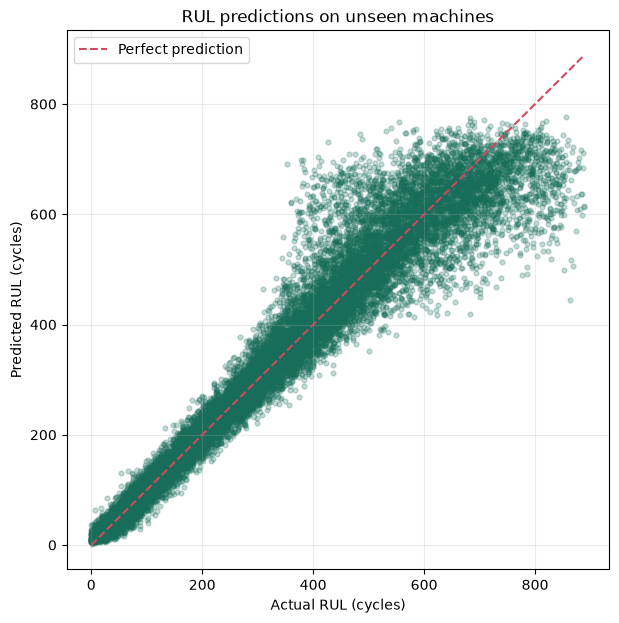

In [12]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    rul_predictions,
    alpha=0.25,
    s=12,
    color="#176D59",
)

max_rul = max(y_test.max(), rul_predictions.max())

plt.plot(
    [0, max_rul],
    [0, max_rul],
    "--",
    color="#D1495B",
    label="Perfect prediction",
)

plt.xlabel("Actual RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("RUL predictions on unseen machines")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

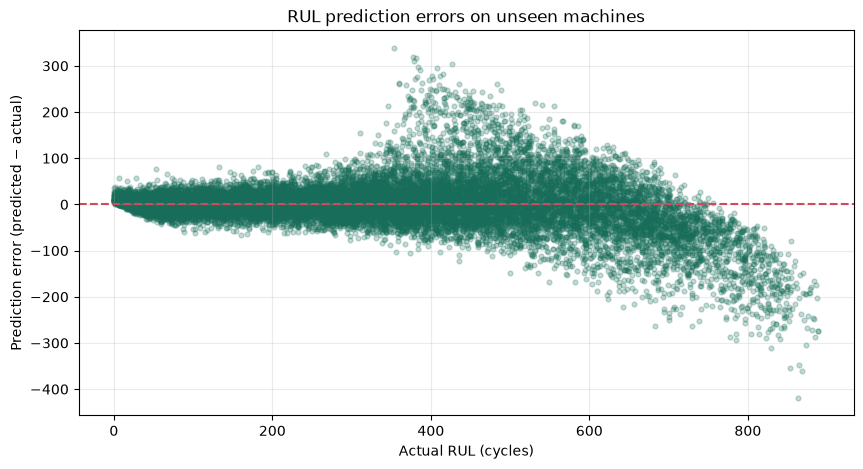

In [13]:
residuals = rul_predictions - y_test

plt.figure(figsize=(10, 5))

plt.scatter(
    y_test,
    residuals,
    alpha=0.25,
    s=12,
    color="#176D59",
)

plt.axhline(0, linestyle="--", color="#D1495B")

plt.xlabel("Actual RUL (cycles)")
plt.ylabel("Prediction error (predicted − actual)")
plt.title("RUL prediction errors on unseen machines")
plt.grid(alpha=0.25)
plt.show()

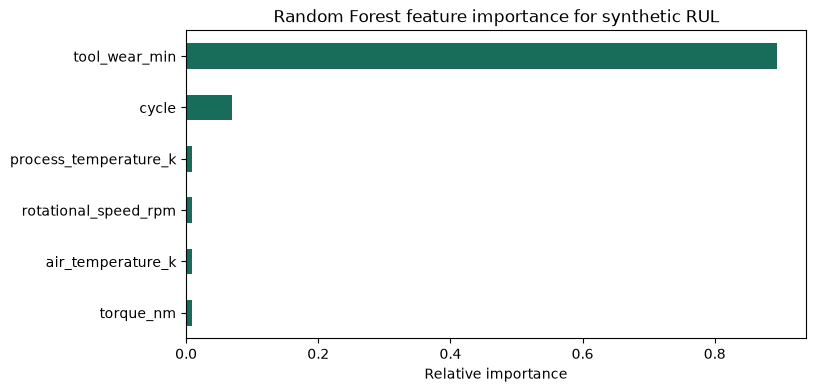

In [14]:
feature_importance = (
    pd.Series(
        rul_model.feature_importances_,
        index=rul_feature_columns,
    )
    .sort_values()
)

feature_importance.plot.barh(
    figsize=(8, 4),
    color="#176D59",
    title="Random Forest feature importance for synthetic RUL",
)

plt.xlabel("Relative importance")
plt.show()

In [15]:
absolute_errors = np.abs(residuals)

rul_safety_buffer = float(np.percentile(absolute_errors, 80))

print(f"80th-percentile absolute error: {rul_safety_buffer:.1f} cycles")
print(
    "Conservative RUL formula: "
    "max(0, predicted RUL − safety buffer)"
)

80th-percentile absolute error: 51.7 cycles
Conservative RUL formula: max(0, predicted RUL − safety buffer)


In [16]:
import joblib
from pathlib import Path

rul_bundle = {
    "model": rul_model,
    "feature_names": rul_feature_columns,
    "safety_buffer_cycles": rul_safety_buffer,
    "model_name": "Random Forest synthetic-RUL v1",
    "training_data_note": "Synthetic run-to-failure simulation",
}

rul_model_path = Path("../models/rul_model.joblib")

joblib.dump(rul_bundle, rul_model_path, compress=("xz", 3))

print(f"Saved RUL model to: {rul_model_path.resolve()}")

Saved RUL model to: D:\Stuff\Coding\SentinelAI\models\rul_model.joblib


In [17]:
loaded_rul_bundle = joblib.load(rul_model_path)

sample_features = X_test.iloc[[0]]

predicted_rul = float(
    loaded_rul_bundle["model"].predict(sample_features)[0]
)

conservative_rul = max(
    0,
    predicted_rul - loaded_rul_bundle["safety_buffer_cycles"],
)

print(f"Actual RUL: {y_test.iloc[0]:.1f} cycles")
print(f"Predicted RUL: {predicted_rul:.1f} cycles")
print(f"Conservative planning RUL: {conservative_rul:.1f} cycles")

Actual RUL: 742.0 cycles
Predicted RUL: 684.6 cycles
Conservative planning RUL: 632.9 cycles
